<a href="https://colab.research.google.com/github/BryanHinostroza/lab09-bh/blob/develop/SEMANA_9_REDES_NEURONALES_ARTIFICIALES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte A: Red Neuronal con el dataset de Cáncer de Mama (UCI)

Importar librerías necesarias

In [ ]:
"""
Import necessary Python libraries for data handling, preprocessing, modeling, and evaluation.
"""
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Cargar y preprocesar datos

In [ ]:
"""
Retrieve data from a csv into a dataframe.
Input:
- url: URL of the CSV file from UCI repository
Output:
- Cleaned dataframe with numerical values and target encoded as binary
"""
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
columnas = ["ID", "ClumpThickness", "UniformityCellSize", "UniformityCellShape",
            "MarginalAdhesion", "SingleEpithelialCellSize", "BareNuclei",
            "BlandChromatin", "NormalNucleoli", "Mitoses", "Class"]

df = pd.read_csv(url, names=columnas)

# Handle missing values and data types
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)
df["BareNuclei"] = df["BareNuclei"].astype(int)

# Drop ID column
df.drop("ID", axis=1, inplace=True)

# Map class labels: 2 (benign) -> 0, 4 (malignant) -> 1
df["Class"] = df["Class"].map({2: 0, 4: 1})



Dividir y escalar los datos

In [ ]:
"""
Split dataset into train and test sets (80/20) and apply feature scaling.
Output:
- Scaled training and test datasets
"""
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Entrenar red neuronal MLP con parámetros base

In [ ]:
"""
Train a multilayer perceptron (MLP) classifier on the scaled training data.
Hyperparameters can be tuned to improve accuracy.
"""
mlp = MLPClassifier(hidden_layer_sizes=(50, 25),  # Number of neurons in hidden layers
                    max_iter=1000,
                    activation='relu',
                    solver='adam',
                    random_state=42)

mlp.fit(X_train_scaled, y_train)



MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)

Evaluar rendimiento

In [ ]:
"""
Evaluate the MLP classifier on the test set using accuracy, classification report, and confusion matrix.
"""
y_pred = mlp.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9781021897810219

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98        79
           1       0.97      0.98      0.97        58

    accuracy                           0.98       137
   macro avg       0.98      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137

Confusion Matrix:
 [[77  2]
 [ 1 57]]


Entrenar modelo alternativo

In [ ]:
"""
Train an alternative MLP classifier with different hyperparameters to evaluate accuracy improvements.
"""

mlp_alt = MLPClassifier(hidden_layer_sizes=(100, 50, 25),
                        activation='tanh',
                        solver='sgd',
                        learning_rate_init=0.01,
                        max_iter=1500,
                        random_state=42)

mlp_alt.fit(X_train_scaled, y_train)


MLPClassifier(activation='tanh', hidden_layer_sizes=(100, 50, 25),
              learning_rate_init=0.01, max_iter=1500, random_state=42,
              solver='sgd')

Evaluar nuevo modelo

In [ ]:
"""
Evaluate the alternative MLP model on the test set and compare it with the previous model.
"""
y_pred_alt = mlp_alt.predict(X_test_scaled)

print("🔁 Alternative MLP Accuracy:", accuracy_score(y_test, y_pred_alt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_alt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_alt))


🔁 Alternative MLP Accuracy: 0.9635036496350365

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        79
           1       0.98      0.93      0.96        58

    accuracy                           0.96       137
   macro avg       0.97      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137

Confusion Matrix:
 [[78  1]
 [ 4 54]]


# Parte B - Red neuronal convolucional con Fashion MNIST


Importar librerías

In [ ]:
"""
Import necessary TensorFlow and Keras libraries for CNN model development.
"""
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


Cargar y preprocesar datos

In [ ]:
"""
Load the Fashion MNIST dataset and preprocess it.
Output:
- Scaled and reshaped training and test datasets with one-hot encoded labels.
"""
# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Reshape to include channel dimension and scale pixel values to [0, 1]
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Definir la arquitectura de la CNN

In [ ]:
"""
Define the convolutional neural network (CNN) architecture.
Returns:
- Compiled CNN model.
"""
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 classes
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenar el modelo

In [ ]:
"""
Train the CNN model on the training dataset.
Returns:
- Training history including accuracy and loss.
"""
history = model.fit(X_train, y_train_cat,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.7150 - loss: 0.7973 - val_accuracy: 0.8643 - val_loss: 0.3726
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8647 - loss: 0.3773 - val_accuracy: 0.8812 - val_loss: 0.3253
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.8833 - loss: 0.3202 - val_accuracy: 0.8855 - val_loss: 0.3052
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8926 - loss: 0.2884 - val_accuracy: 0.8983 - val_loss: 0.2801
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 39ms/step - accuracy: 0.9023 - loss: 0.2651 - val_accuracy: 0.8923 - val_loss: 0.2870
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.9140 - loss: 0.2349 - val_accuracy: 0.9112 - val_loss: 0.2467
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9165 - loss: 0.2210 - val_accuracy: 0.9122 - val_loss: 0.2473
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9239 - loss: 0.2048 - 

Evaluar el modelo

In [ ]:
"""
Evaluate the CNN model on the test dataset.
Output:
- Accuracy of the model on unseen data.
"""
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9090


Graficar evolución del entrenamiento

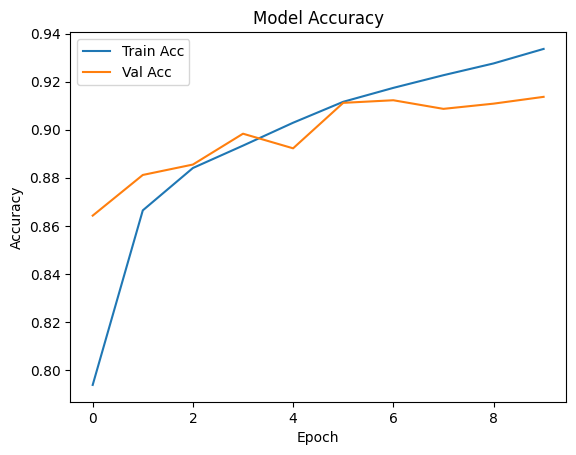

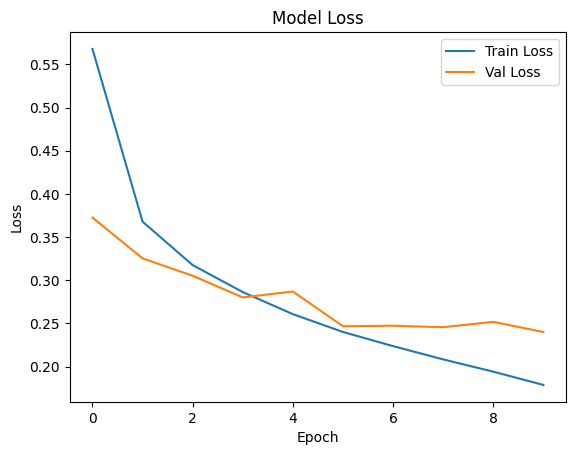

In [ ]:
"""
Plot training and validation accuracy/loss to analyze model performance over epochs.
"""
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
